# Country-Level CO₂ Emissions Forecasting
## Time-Series Machine Learning Project

**Methodology:** CRISP-DM

**Dataset:** Our World in Data CO₂ dataset  
**Target:** `co2`  
**Unit of analysis:** Country-year  
**Country identifier:** `iso_code`  
**Historical period:** 1950 onward

### Project purpose
This notebook develops a country-level time-series forecasting pipeline for annual CO₂ emissions. It follows the **CRISP-DM** methodology and deliberately separates past information from future information to avoid data leakage.

The project asks:

1. **How accurately can historical CO₂ emissions be used to predict future CO₂ emissions for individual countries?**
2. **Which economic, population and energy-related factors are most useful for predicting future CO₂ emissions?**
3. **How do CO₂ emission trends differ across countries over time?**
4. **Can a single forecasting model accurately predict CO₂ emissions across countries using ISO codes and historical characteristics?**
5. **Which time-series modelling approach provides the most accurate CO₂ forecasts?**
6. **How far into the future can CO₂ emissions be forecast with acceptable prediction accuracy?**
7. **Which countries are expected to experience increasing or decreasing CO₂ emissions based on historical trends?**

## CRISP-DM Project Structure

This notebook is organised according to the six CRISP-DM phases:

1. **Business Understanding** — define the CO₂ forecasting problem, business objectives, research questions and success criteria.
2. **Data Understanding** — inspect the OWID dataset, assess variables and missingness, and perform exploratory data analysis.
3. **Data Preparation** — clean the country-year data, handle invalid/missing observations, prepare time-series data and engineer leakage-safe predictors.
4. **Modeling** — establish a persistence baseline, compare the existing feature-based models, tune the selected model, and compare ARIMA vs Prophet for forecasting future predictor variables.
5. **Evaluation** — evaluate the final CO₂ model on an untouched chronological test period, analyse errors and explain the model.
6. **Deployment** — accept a user-selected future year, forecast the required features, generate country-level CO₂ forecasts, and translate results into business insights.

**Important:** the final production forecast is only generated after model selection and evaluation. This prevents information from the requested future year from leaking into model development.

## 1. Business Understanding

### 1.1 Business problem

National CO₂ emissions are influenced by economic activity, population and energy use. The purpose of this project is to use historical country-level information to forecast **next-year CO₂ emissions** and identify patterns that can support emissions planning and monitoring.

### 1.2 Business objective

Develop an accurate, reproducible and interpretable forecasting approach for country-level CO₂ emissions using historical emissions, economic, population and energy-related variables.

### 1.3 Research questions

1. How accurately can historical CO₂ emissions predict future CO₂ emissions for individual countries?
2. Which economic, population and energy-related variables are useful for forecasting future CO₂ emissions?
3. How do CO₂ emission patterns differ across countries and over time?
4. Which forecasting model provides the best predictive performance?
5. Can the selected approach generate country-level forecasts for future years?

### 1.4 Metrics of success

The project will be considered successful when the modelling process: 
- uses a **chronological train/validation/test split** with no future information entering the training data;
- establishes a **naive persistence baseline** before applying machine-learning models;
- achieves lower **MAE** and **RMSE** than the baseline where possible;
- achieves a strong **R²** without relying on R² alone;
- demonstrates that missing values, duplicates and invalid values are handled systematically;
- compares several candidate models on the same validation period;
- uses **hyperparameter tuning** on the training data only;
- evaluates the selected model once on the untouched test period; and
- produces usable country-level forecasts for the next year.

**Metric interpretation:** MAE and RMSE should be minimised, while R² should be maximised. RMSE is particularly useful for identifying large forecasting errors because it penalises larger errors more heavily.

**Research context:** The project is informed by IPCC AR6 findings on socioeconomic and energy drivers of emissions and previous country-level CO₂ forecasting research such as Costantini et al. (2024).


## 2. Data Understanding

### 2.1. Data Source

The project uses the **Our World in Data (OWID) CO₂ and Greenhouse Gas Emissions Dataset**, which provides comprehensive country-level annual data from 1950 to 2024.

**Dataset characteristics**:
- **Coverage**: 250+ countries and regional aggregates
- **Time span**: 1950-2024 (75 years of historical data)
- **Update frequency**: Regular updates as new data becomes available
- **Format**: CSV with country, year, and multiple emission/socioeconomic indicators

### 2.2. Key Variables for Forecasting

**Target Variable**:
- `co2`: Total CO₂ emissions (in million tonnes)

**Primary Features** (grouped by category):

| Category | Variables | Purpose |
|----------|-----------|---------|
| **Temporal** | `year`, lagged CO₂ values | Capture time trends and momentum |
| **Demographic** | `population`, `population_density` | Control for country size and urbanization |
| **Economic** | `gdp`, `gdp_per_capita` | Proxy for economic activity level |
| **Energy** | `primary_energy_consumption`, `energy_per_capita`, `energy_intensity_level_of_ppp_gdp` | Reflect energy infrastructure and efficiency |
| **Emission Composition** | `coal_co2`, `oil_co2`, `gas_co2`, `cement_co2`, `flaring_co2` | Identify primary emission sources by fuel type |

### 2.3. Data Characteristics

- **Missing values**: Unevenly distributed across countries and time periods (e.g., developing nations have sparse early records)
- **Temporal ordering**: Sequential annual observations; must preserve temporal order in train/test splits
- **Scale variation**: Emissions range from near-zero (small island nations) to billions of tonnes (China, USA); requires normalization/scaling
- **Regional patterns**: Developed nations show stable/declining trends; emerging economies show growth; requires country-level modeling consideration

In [202]:
# Importing the neccesary libraries
# Removing warning and logs
import warnings
warnings.filterwarnings("ignore")
import logging
logging.getLogger("cmdstanpy").setLevel(logging.WARNING)
import cmdstanpy
cmdstanpy.utils.get_logger().setLevel(logging.ERROR)

# Data manipulation
import pandas as pd
pd.set_option('display.max_rows', None) # Allows the rows to be shown in full
pd.set_option('display.max_columns', None) # Allows the columns to be shown in full
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Models
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

In [203]:
# Loading the dataset
df_raw = pd.read_csv('owid-co2-data.csv')
df_raw.head()

,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,co2_including_luc,co2_including_luc_growth_abs,co2_including_luc_growth_prct,co2_including_luc_per_capita,co2_including_luc_per_gdp,co2_including_luc_per_unit_energy,co2_per_capita,co2_per_gdp,co2_per_unit_energy,coal_co2,coal_co2_per_capita,consumption_co2,consumption_co2_per_capita,consumption_co2_per_gdp,cumulative_cement_co2,cumulative_co2,cumulative_co2_including_luc,cumulative_coal_co2,cumulative_flaring_co2,cumulative_gas_co2,cumulative_luc_co2,cumulative_oil_co2,cumulative_other_co2,energy_per_capita,energy_per_gdp,flaring_co2,flaring_co2_per_capita,gas_co2,gas_co2_per_capita,ghg_excluding_lucf_per_capita,ghg_per_capita,land_use_change_co2,land_use_change_co2_per_capita,methane,methane_per_capita,nitrous_oxide,nitrous_oxide_per_capita,oil_co2,oil_co2_per_capita,other_co2_per_capita,other_industry_co2,primary_energy_consumption,share_global_cement_co2,share_global_co2,share_global_co2_including_luc,share_global_coal_co2,share_global_cumulative_cement_co2,share_global_cumulative_co2,share_global_cumulative_co2_including_luc,share_global_cumulative_coal_co2,share_global_cumulative_flaring_co2,share_global_cumulative_gas_co2,share_global_cumulative_luc_co2,share_global_cumulative_oil_co2,share_global_cumulative_other_co2,share_global_flaring_co2,share_global_gas_co2,share_global_luc_co2,share_global_oil_co2,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
0,Afghanistan,1750,AFG,2802560.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,1751,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,1752,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,1753,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,1754,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [204]:
# Checking the shape of the dataset
df_raw.shape

(50411, 79)

This dataset contains **50411** rows and **79** columns

In [205]:
# Checking the datatypes of the columns
df_raw.dtypes

country                                          str
year                                           int64
iso_code                                         str
population                                   float64
gdp                                          float64
cement_co2                                   float64
cement_co2_per_capita                        float64
co2                                          float64
co2_growth_abs                               float64
co2_growth_prct                              float64
co2_including_luc                            float64
co2_including_luc_growth_abs                 float64
co2_including_luc_growth_prct                float64
co2_including_luc_per_capita                 float64
co2_including_luc_per_gdp                    float64
co2_including_luc_per_unit_energy            float64
co2_per_capita                               float64
co2_per_gdp                                  float64
co2_per_unit_energy                          f

Most of the columns in the dataset are numerical (int 64 & float 64) and there are two columns which are string datatype which are country and iso_code.

The year is int 64 instead of datetime so we'll have to change to datetime.

In [206]:
# Checking the information of the dataset
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 50411 entries, 0 to 50410
Data columns (total 79 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   country                                    50411 non-null  str    
 1   year                                       50411 non-null  int64  
 2   iso_code                                   42480 non-null  str    
 3   population                                 41167 non-null  float64
 4   gdp                                        15251 non-null  float64
 5   cement_co2                                 29173 non-null  float64
 6   cement_co2_per_capita                      25648 non-null  float64
 7   co2                                        29384 non-null  float64
 8   co2_growth_abs                             27216 non-null  float64
 9   co2_growth_prct                            26239 non-null  float64
 10  co2_including_luc                

It appears that there are missing data in the dataset.

In [207]:
# Checking for missing data (count and percentage)
missing_summary = pd.DataFrame({
    'Missing Count': df_raw.isna().sum(),
    'Missing Percent': df_raw.isna().mean() * 100
})

missing_summary['Combined'] = (
    missing_summary['Missing Count'].astype(str)
    + " ("
    + missing_summary['Missing Percent'].round(2).astype(str)
    + "%)"
)

missing_summary.round(2)

,Missing Count,Missing Percent,Combined
country,0,0.00,0 (0.0%)
year,0,0.00,0 (0.0%)
iso_code,7931,15.73,7931 (15.73%)
population,9244,18.34,9244 (18.34%)
gdp,35160,69.75,35160 (69.75%)
cement_co2,21238,42.13,21238 (42.13%)
cement_co2_per_capita,24763,49.12,24763 (49.12%)
co2,21027,41.71,21027 (41.71%)
co2_growth_abs,23195,46.01,23195 (46.01%)
co2_growth_prct,24172,47.95,24172 (47.95%)


The above are the number of missing data and their percentage of every column in the dataset.

This dataset has alot of missing data some columns even has as far as 90% missing data. We'll have to take a closer look at the data and remove some columns if necessary.

In [208]:
# Checking the feature/column names
df_raw.columns

Index(['country', 'year', 'iso_code', 'population', 'gdp', 'cement_co2',
       'cement_co2_per_capita', 'co2', 'co2_growth_abs', 'co2_growth_prct',
       'co2_including_luc', 'co2_including_luc_growth_abs',
       'co2_including_luc_growth_prct', 'co2_including_luc_per_capita',
       'co2_including_luc_per_gdp', 'co2_including_luc_per_unit_energy',
       'co2_per_capita', 'co2_per_gdp', 'co2_per_unit_energy', 'coal_co2',
       'coal_co2_per_capita', 'consumption_co2', 'consumption_co2_per_capita',
       'consumption_co2_per_gdp', 'cumulative_cement_co2', 'cumulative_co2',
       'cumulative_co2_including_luc', 'cumulative_coal_co2',
       'cumulative_flaring_co2', 'cumulative_gas_co2', 'cumulative_luc_co2',
       'cumulative_oil_co2', 'cumulative_other_co2', 'energy_per_capita',
       'energy_per_gdp', 'flaring_co2', 'flaring_co2_per_capita', 'gas_co2',
       'gas_co2_per_capita', 'ghg_excluding_lucf_per_capita', 'ghg_per_capita',
       'land_use_change_co2', 'land_use_chang

The above is all the names of the columns in this dataset.

In [209]:
# checking the description of the dataset
df_raw.describe()

,year,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,co2_including_luc,co2_including_luc_growth_abs,co2_including_luc_growth_prct,co2_including_luc_per_capita,co2_including_luc_per_gdp,co2_including_luc_per_unit_energy,co2_per_capita,co2_per_gdp,co2_per_unit_energy,coal_co2,coal_co2_per_capita,consumption_co2,consumption_co2_per_capita,consumption_co2_per_gdp,cumulative_cement_co2,cumulative_co2,cumulative_co2_including_luc,cumulative_coal_co2,cumulative_flaring_co2,cumulative_gas_co2,cumulative_luc_co2,cumulative_oil_co2,cumulative_other_co2,energy_per_capita,energy_per_gdp,flaring_co2,flaring_co2_per_capita,gas_co2,gas_co2_per_capita,ghg_excluding_lucf_per_capita,ghg_per_capita,land_use_change_co2,land_use_change_co2_per_capita,methane,methane_per_capita,nitrous_oxide,nitrous_oxide_per_capita,oil_co2,oil_co2_per_capita,other_co2_per_capita,other_industry_co2,primary_energy_consumption,share_global_cement_co2,share_global_co2,share_global_co2_including_luc,share_global_coal_co2,share_global_cumulative_cement_co2,share_global_cumulative_co2,share_global_cumulative_co2_including_luc,share_global_cumulative_coal_co2,share_global_cumulative_flaring_co2,share_global_cumulative_gas_co2,share_global_cumulative_luc_co2,share_global_cumulative_oil_co2,share_global_cumulative_other_co2,share_global_flaring_co2,share_global_gas_co2,share_global_luc_co2,share_global_oil_co2,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
count,50411.000000,4.116700e+04,1.525100e+04,29173.000000,25648.000000,29384.000000,27216.000000,26239.000000,23796.000000,23496.000000,23496.000000,23757.000000,16790.000000,10133.000000,26509.000000,17528.000000,10826.000000,21925.000000,21314.000000,5053.000000,4643.000000,4448.000000,29151.000000,2.756300e+04,2.379600e+04,21925.000000,16111.000000,18147.000000,37450.000000,25458.000000,3254.000000,10586.000000,7787.000000,16174.000000,14910.000000,18147.000000,17446.000000,35842.00000,36179.000000,37450.000000,36635.000000,38150.000000,36179.000000,38500.000000,36439.000000,25459.000000,24722.000000,2659.000000,3254.000000,10631.000000,22270.000000,27563.000000,23796.000000,21925.000000,22270.000000,27563.000000,23796.000000,21925.000000,11089.000000,15167.000000,37450.000000,23833.000000,2170.000000,11089.000000,15167.000000,37450.000000,23833.000000,2170.000000,41238.000000,38280.000000,41238.000000,41238.000000,38280.000000,38150.000000,37813.000000,4712.000000,4712.000000
mean,1920.349249,6.017294e+07,3.300495e+11,7.890109,0.060026,420.227035,6.268847,42.598225,544.144592,7.483698,4.132343,7.115447,2.328426,1343.224898,3.821411,0.397679,251.177589,185.496070,1.285324,1318.129607,6.463631,0.349924,196.486344,1.249223e+04,2.790247e+04,9311.023979,177.231149,1876.820098,9998.375654,3777.605153,417.861562,24218.017776,1.672906,5.854644,0.270544,74.840369,0.797032,3.07991,7.716833,124.752927,3.905510,95.277707,1.741468,25.424751,0.444591,115.307630,2.192718,0.082205,20.116569,2450.931544,3.002813,5.369860,3.457512,6.791725,2.995657,5.500642,3.321957,6.974350,3.043673,4.104541,2.559362,3.351795,7.053671,3.126383,4.195698,2.439717,3.333339,7.190616,2.272236,0.002871,0.008014,0.011224,0.000509,490.799608,310.521459,-6.986781,21.468641
std,65.859123,3.308412e+08,3.086383e+12,62.988171,0.123566,1972.092032,62.199548,1721.913018,2273.281696,99.512520,166.964358,8.921137,5.626872,6678.225759,14.312856,0.754065,315.226128,855.418419,2.351089,3904.104954,6.852299,0.247281,1495.918343,7.312143e+04,1.269563e+05,43499.981365,926.732659,11756.922691,46043.141427,24886.829185,1317.317547,32203.518384,1.629769,26.749898,2.995049,397.296985,2.805144,7.78545,11.276765,519.818810,9.106597,434.707032,3.832696,129.896895,0.799286,646.556645,13.948769,0.079726,55.644708,11383.276535,13.389959,18.734892,11.709725,20.969463

The dataset appears to have skewed features/columns and we'll have to consider during cleaning

### Missing-value assessment — first cleaning step

Missing values are assessed before dropping or imputing anything. This prevents important information from being removed without understanding where and why values are missing. The target variable (`co2`) is treated differently from predictors: rows without a usable target cannot contribute to supervised training, while missing predictor values can later be handled by the preprocessing pipeline.


In [210]:
# Missing-value audit on the raw dataset
missing_summary = pd.DataFrame({
    'Missing Count': df_raw.isna().sum(),
    'Missing Percentage': (df_raw.isna().mean() * 100).round(2)
}).sort_values('Missing Percentage', ascending=False)

missing_summary.head(20)

,Missing Count,Missing Percentage
share_global_cumulative_other_co2,48241,95.70
share_global_other_co2,48241,95.70
other_co2_per_capita,47752,94.73
cumulative_other_co2,47157,93.55
other_industry_co2,47157,93.55
consumption_co2_per_gdp,45963,91.18
consumption_co2_per_capita,45768,90.79
trade_co2,45699,90.65
trade_co2_share,45699,90.65
consumption_co2,45358,89.98


### Duplicate assessment

For a country-level annual time series, each **country-year** should represent one observation. Duplicate country-year records can distort trends, correlations and lag calculations, so they must be identified and removed before time-series preprocessing.


In [211]:
# Check duplicate country-year observations
duplicate_count = df_raw.duplicated(subset=['iso_code', 'year']).sum()
print('Duplicate country-year rows:', duplicate_count)

# Inspect duplicate country-year records if any exist
duplicates = df_raw[df_raw.duplicated(subset=['iso_code', 'year'], keep=False)].sort_values(['iso_code', 'year'])
duplicates.head(20)

Duplicate country-year rows: 7656


,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,co2_including_luc,co2_including_luc_growth_abs,co2_including_luc_growth_prct,co2_including_luc_per_capita,co2_including_luc_per_gdp,co2_including_luc_per_unit_energy,co2_per_capita,co2_per_gdp,co2_per_unit_energy,coal_co2,coal_co2_per_capita,consumption_co2,consumption_co2_per_capita,consumption_co2_per_gdp,cumulative_cement_co2,cumulative_co2,cumulative_co2_including_luc,cumulative_coal_co2,cumulative_flaring_co2,cumulative_gas_co2,cumulative_luc_co2,cumulative_oil_co2,cumulative_other_co2,energy_per_capita,energy_per_gdp,flaring_co2,flaring_co2_per_capita,gas_co2,gas_co2_per_capita,ghg_excluding_lucf_per_capita,ghg_per_capita,land_use_change_co2,land_use_change_co2_per_capita,methane,methane_per_capita,nitrous_oxide,nitrous_oxide_per_capita,oil_co2,oil_co2_per_capita,other_co2_per_capita,other_industry_co2,primary_energy_consumption,share_global_cement_co2,share_global_co2,share_global_co2_including_luc,share_global_coal_co2,share_global_cumulative_cement_co2,share_global_cumulative_co2,share_global_cumulative_co2_including_luc,share_global_cumulative_coal_co2,share_global_cumulative_flaring_co2,share_global_cumulative_gas_co2,share_global_cumulative_luc_co2,share_global_cumulative_oil_co2,share_global_cumulative_other_co2,share_global_flaring_co2,share_global_gas_co2,share_global_luc_co2,share_global_oil_co2,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
275,Africa,1750,NaN,79382032.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2679,Asia,1750,NaN,498699232.0,NaN,0.0,0.0,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.000,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3129,Asia (excl. China and India),1750,NaN,NaN,NaN,0.0,0.0,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.000,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14993,Europe,1750,NaN,154836912.0,NaN,0.0,0.0,9.306,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.062,NaN,NaN,9.306,0.062,NaN,NaN,NaN,0.0,9.306,NaN,9.306,0.0,0.0,NaN,0.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,100.0,NaN,100.0,NaN,100.0,NaN,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15443,Europe (excl. EU-27),1750,NaN,NaN,NaN,0.0,0.0,9.306,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.214,NaN,NaN,9.306,0.214,NaN,NaN,NaN,0.0,9.306,NaN,9.306,0.0,0.0,NaN,0.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,100.0,NaN,100.0,NaN,100.0,NaN,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15718,Europe (excl. EU-28),1750,NaN,NaN,NaN,0.0,0.0,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.000,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15993,European Union (27),1750,NaN,106479340.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

### Invalid and inconsistent values

Infinite values can arise from ratios or calculations and are not valid model inputs. They are converted to `NaN` so that they can be handled consistently. Country records without an ISO code are excluded because the project models countries rather than aggregates such as continents or income groups.


In [212]:
# Check invalid infinite values before further cleaning
infinite_counts = pd.Series(np.isinf(df_raw.select_dtypes(include=np.number)).sum())
infinite_counts[infinite_counts > 0].sort_values(ascending=False).head(20)

Series([], dtype: int64)

### 2.4 Exploratory Data Analysis (EDA)

EDA is performed at three levels: **univariate, bivariate and multivariate**. This helps understand individual variable distributions, pairwise relationships and interactions among several variables before final modelling.

#### 2.4.1 Univariate EDA

Univariate analysis examines one variable at a time. For this project it is used to understand the distribution, scale, skewness and extreme values of CO₂ emissions, GDP, population and energy consumption. This is important because CO₂ data are highly uneven across countries and large emitters can dominate absolute values.


In [213]:
# Prepare an inspection view for EDA without applying final modelling transformations.
# This keeps EDA within CRISP-DM Phase 2 (Data Understanding).
eda_data = df_raw[(df_raw['iso_code'].notna()) & (df_raw['year'] >= 1950)].copy()
eda_data = eda_data.sort_values(['country', 'year'])


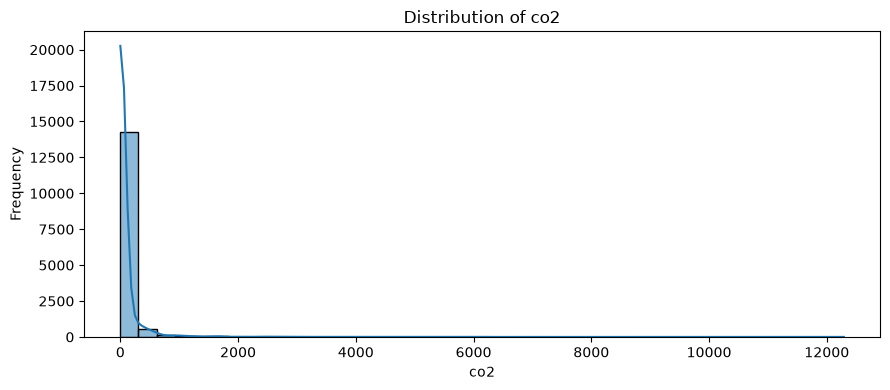

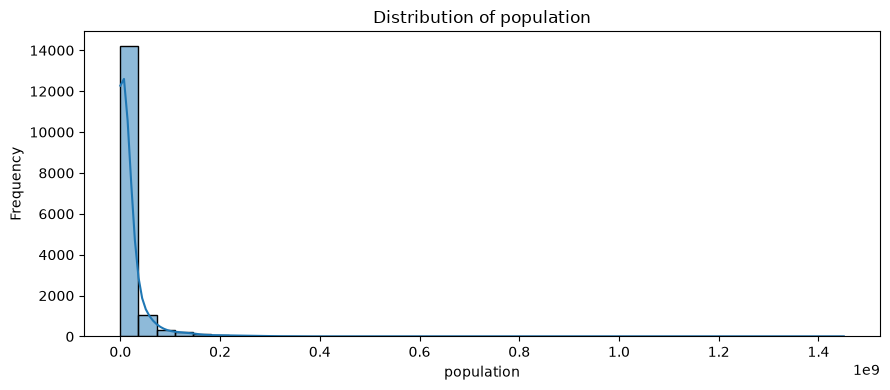

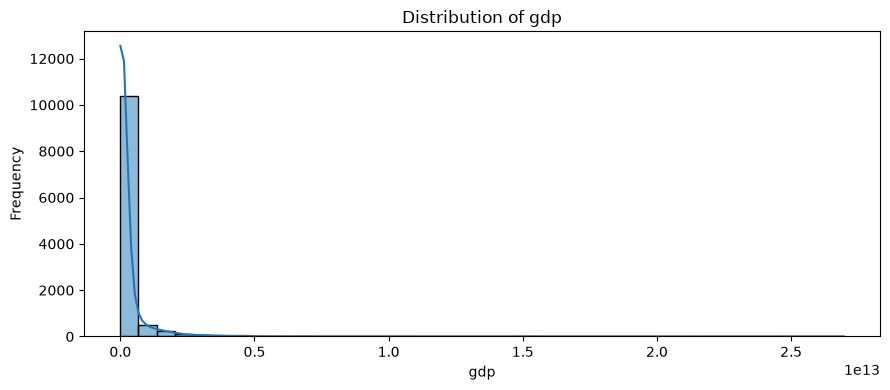

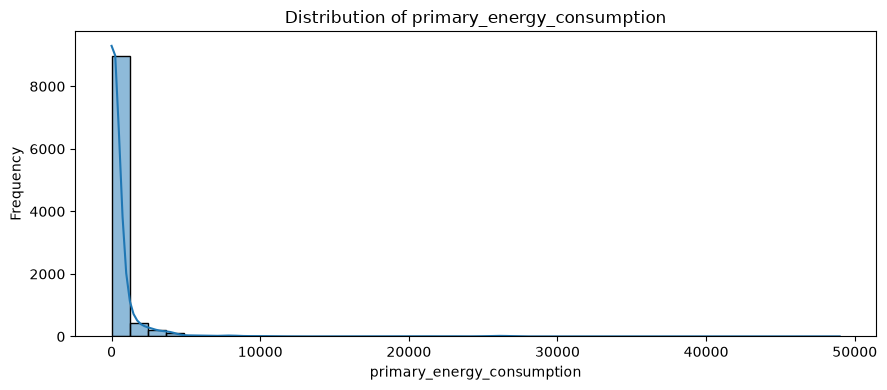

In [214]:
# Univariate EDA: distribution of key numerical variables
eda_cols = ['co2', 'population', 'gdp', 'primary_energy_consumption']

for col in eda_cols:
    if col in eda_data.columns:
        plt.figure(figsize=(9, 4))
        sns.histplot(eda_data[col].dropna(), bins=40, kde=True)
        plt.title(f'Distribution of {col}')
        plt.xlabel(col)
        plt.ylabel('Frequency')
        plt.tight_layout()
        plt.show()

#### 2.4.2.1. Bivariate EDA: CO₂ Over Time

A time-series line plot examines the relationship between **year and CO₂ emissions**. This identifies long-term trends, periods of rapid growth or decline and the strong persistence that motivates a naive forecasting benchmark.


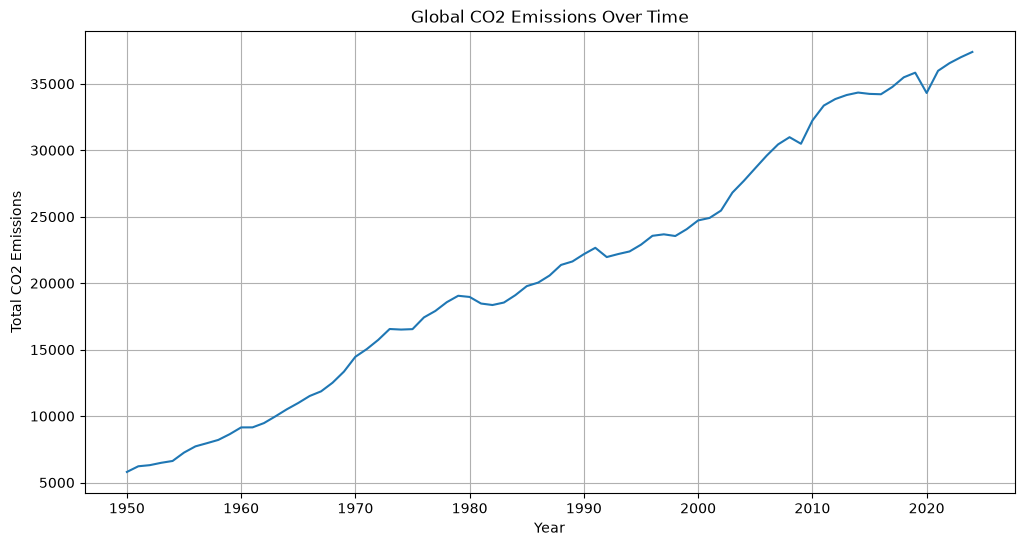

In [215]:
# create a line plot that shows the total co2 emissions over time. i want to show the global emissions.
df_global = eda_data.groupby('year')['co2'].sum().reset_index()

plt.figure(figsize=(12,6))
plt.plot(df_global['year'], df_global['co2'])
plt.title('Global CO2 Emissions Over Time')
plt.xlabel('Year')
plt.ylabel('Total CO2 Emissions')
plt.grid(True)
plt.show()

Global CO₂ emissions show a strong long-term upward trend, rising substantially from 1950 to the most recent years. The main noticeable declines occur around the early 1980s and early 1990s, periods associated with economic slowdowns and reduced energy demand. A sharper decline occurs around 2009 following the global financial crisis, while the largest recent drop is around 2020, largely associated with COVID-19 restrictions that temporarily reduced transportation, industrial activity, and energy use. Emissions rebounded quickly afterward and reached new highs, showing that the overall long-term trend remains upward.

#### 2.4.2.2. Bivariate EDA: Country and Cumulative CO₂ Emissions

Comparing country-level cumulative emissions shows how unevenly emissions are distributed across countries and highlights the importance of retaining country identity as a categorical forecasting feature.


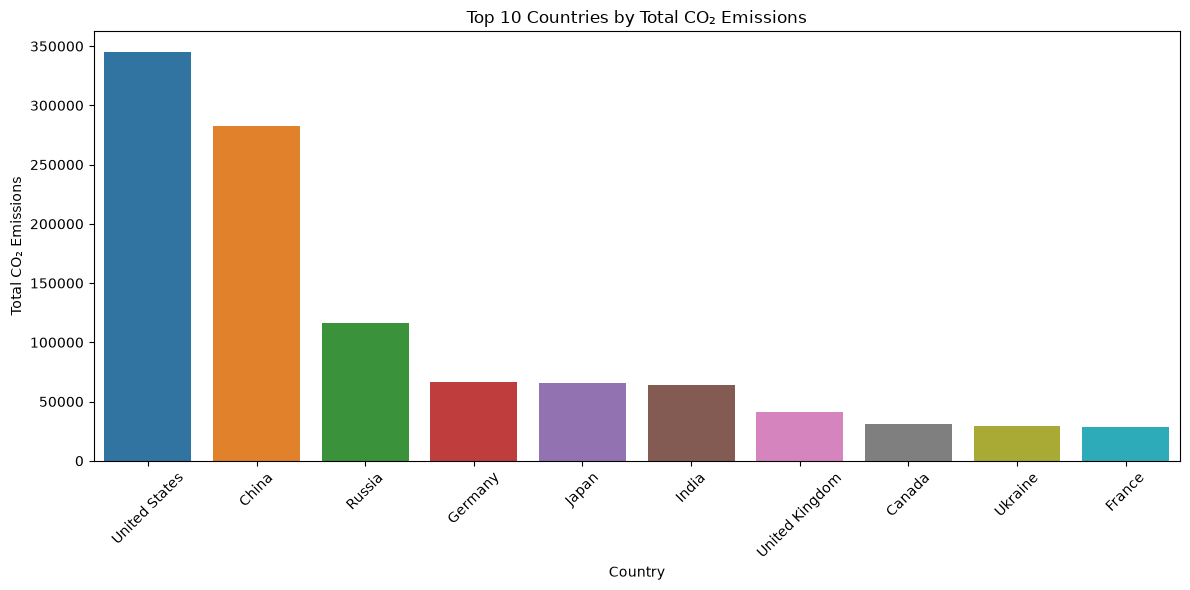

In [216]:
top_emitters = eda_data.groupby("country")["co2"].sum().nlargest(10)

# Create a consistent color palette
colors = sns.color_palette("tab10", n_colors=len(top_emitters))

# Map each country to its assigned color
country_colors = dict(zip(top_emitters.index, colors))

# Plotting top 10 emitting countries
plt.figure(figsize=(12, 6))

sns.barplot(
    x=top_emitters.index,
    y=top_emitters.values,
    palette=country_colors
)

plt.title("Top 10 Countries by Total CO₂ Emissions")
plt.xlabel("Country")
plt.ylabel("Total CO₂ Emissions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The analysis of cumulative CO₂ emissions shows that the **United States is among the largest contributors to total emissions** over the study period. This highlights the significant role of highly industrialized economies in historical global emissions and shows the large differences in emission levels across countries.

#### 2.4.2.3. Bivariate EDA: CO₂ Trends by Country

Country-specific time-series plots compare the direction and rate of change among major emitters. Different trajectories demonstrate why a model needs both temporal information and country-level characteristics.


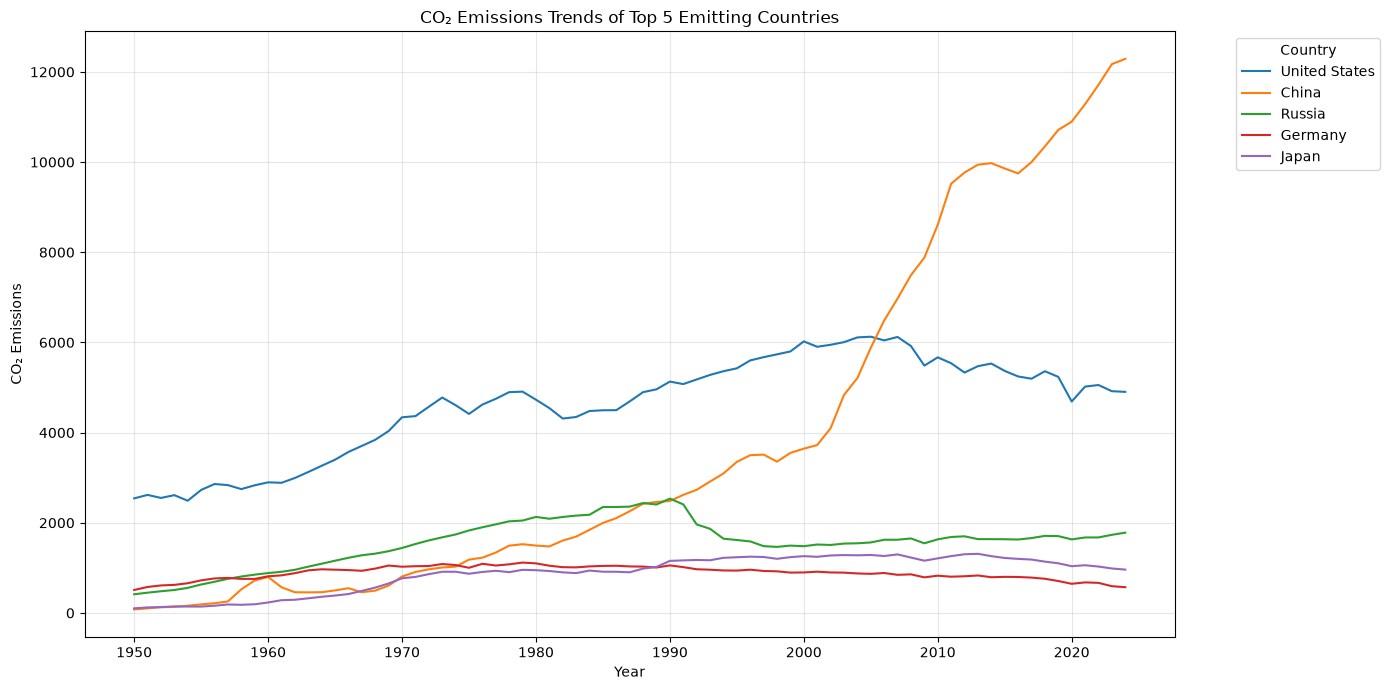

In [217]:
# Identify the top 5 countries by total CO₂ emissions
top_5_countries = top_emitters.head(5).index

top_countries_df = eda_data[
    eda_data["country"].isin(top_5_countries)
]

plt.figure(figsize=(14, 7))

# Plot each country separately
for country in top_5_countries:
    country_data = top_countries_df[
        top_countries_df["country"] == country
    ].sort_values("year")

    plt.plot(
        country_data["year"],
        country_data["co2"],
        label=country
    )

plt.title("CO₂ Emissions Trends of Top 5 Emitting Countries")
plt.xlabel("Year")
plt.ylabel("CO₂ Emissions")

plt.legend(
    title="Country",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

The CO₂ emissions trend shows different patterns among the major emitting countries. The **United States experienced strong emissions growth historically, but its emissions have remained relatively stable and have declined in more recent years**. This can be associated with slower growth in energy demand, improvements in energy efficiency, a shift away from coal, and increased use of cleaner energy sources.

In contrast, **China's CO₂ emissions increased rapidly, particularly from the early 2000s**. This reflects China's rapid industrialization, economic growth, expansion of manufacturing, urbanization, and heavy dependence on coal for energy.

The comparison shows that CO₂ emissions can change significantly as countries move through different stages of **economic development, industrialization, and energy transition**.

#### 2.4.3. Multivariate EDA: Correlation Among Emissions, Energy and Economic Variables

The multivariate correlation matrix examines several variables simultaneously. It helps identify groups of strongly related predictors, possible redundancy and the broader relationship between CO₂, energy consumption, GDP and population.


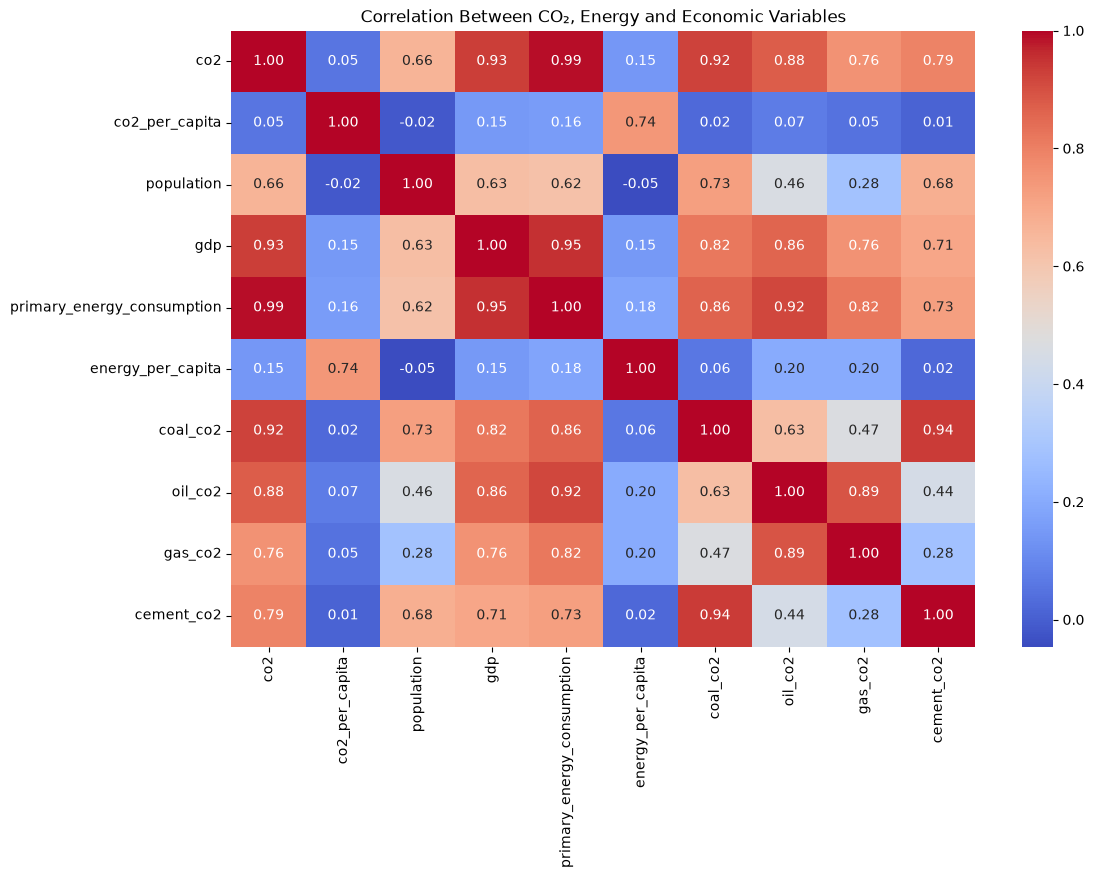

In [218]:
corr_cols = [
    'co2',
    'co2_per_capita',
    'population',
    'gdp',
    'primary_energy_consumption',
    'energy_per_capita',
    'coal_co2',
    'oil_co2',
    'gas_co2',
    'cement_co2'
]

plt.figure(figsize=(12, 8))
sns.heatmap(
    eda_data[corr_cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Between CO₂, Energy and Economic Variables')
plt.show()

## 3. Data Cleaning

**Data cleaning is different from time-series preprocessing.**

- **Data cleaning** makes the raw dataset reliable: missing-value assessment, duplicate detection/removal, invalid-value checks, incorrect records, country filtering and removal of unsuitable observations.
- **Time-series preprocessing** prepares the already-clean data for modelling: chronological ordering, creating the forecasting target, aligning lags/rolling windows, encoding categorical variables, imputing model features and applying transformations inside a modelling pipeline.

The cleaning stage is completed before modelling features are constructed.


### 3.1 Structural Cleaning: Country Filtering and Duplicate Removal

Keep observations with a valid ISO code and remove duplicate country-year observations. This creates one chronological observation per country per year before the historical period and variable-selection steps.


In [219]:
# Keep country-level observations and remove duplicate country-year records
df_countries = df_raw[df_raw['iso_code'].notna()].copy()
df_countries = df_countries.drop_duplicates(subset=['iso_code', 'year'], keep='first')

print('Rows after country filtering and duplicate removal:', len(df_countries))
print('Remaining duplicate country-year rows:', df_countries.duplicated(subset=['iso_code', 'year']).sum())

Rows after country filtering and duplicate removal: 42480
Remaining duplicate country-year rows: 0


### 3.2 Feature Screening and Correlation Assessment

Correlation is assessed after the basic structural cleaning steps. It is used as an **exploratory screening tool**, not as proof of causation. Strongly related variables are investigated because highly redundant predictors can add noise or instability, while variables with useful relationships to CO₂ can inform feature selection and modelling.


In [220]:
# Correlation of numeric variables with the CO2 target
target = 'co2'
correlations = (
    df_countries.select_dtypes(include='number')
    .corr()[target]
    .sort_values(ascending=False)
)

correlations

co2                                          1.000000
total_ghg_excluding_lucf                     0.998848
consumption_co2                              0.993112
primary_energy_consumption                   0.988604
total_ghg                                    0.953452
co2_including_luc                            0.951048
share_global_other_co2                       0.950661
gdp                                          0.924912
coal_co2                                     0.923477
cumulative_coal_co2                          0.893168
other_industry_co2                           0.889258
share_global_cumulative_other_co2            0.884977
temperature_change_from_ghg                  0.882681
nitrous_oxide                                0.880835
oil_co2                                      0.874346
temperature_change_from_ch4                  0.868975
cumulative_cement_co2                        0.866290
cumulative_co2_including_luc                 0.864406
temperature_change_from_n2o 

### 3.3 Selecting Variables for the Forecasting Dataset

The selected variables represent the main dimensions expected to help explain or predict CO₂ emissions: country identity, time, population, economic activity, energy use and emissions-related variables. Variables are retained based on forecasting relevance, data availability and exploratory relationships rather than correlation alone.


In [221]:
# List of the columns to keep
columns_to_keep = ['country', 'year', 'iso_code', 'gdp', 'population', 'co2', 'co2_per_capita', 'flaring_co2', 'cement_co2', 'coal_co2', 'oil_co2', 'gas_co2', 'land_use_change_co2', 'total_ghg', 'other_industry_co2','primary_energy_consumption', 'energy_per_capita','co2_including_luc']

# Keeping relevant columns
df1 = df_countries[columns_to_keep]

### 3.4 Restricting the Historical Period

#### 3.4.1. Checking the missing data by year

In [222]:
# Calculate the overall missing percentage across all other columns per year
missing_pct_by_year = df1.groupby('year').apply(
    lambda x: (x.drop(columns=['year'], errors='ignore').isna().sum().sum() / # sum of missing values across all columns except 'year'
               x.drop(columns=['year'], errors='ignore').size) * 100, # to percent
    include_groups=False # do not include the group keys in the output
)
print(missing_pct_by_year)

year
1750    74.509804
1751    80.693816
1752    80.693816
1753    80.693816
1754    80.693816
1755    80.693816
1756    80.693816
1757    80.693816
1758    80.693816
1759    80.693816
1760    74.509804
1761    80.693816
1762    80.693816
1763    80.693816
1764    80.693816
1765    80.693816
1766    80.693816
1767    80.693816
1768    80.693816
1769    80.693816
1770    74.509804
1771    80.693816
1772    80.693816
1773    80.693816
1774    80.693816
1775    80.693816
1776    80.693816
1777    80.693816
1778    80.693816
1779    80.693816
1780    74.509804
1781    80.693816
1782    80.693816
1783    80.693816
1784    80.693816
1785    80.294118
1786    80.294118
1787    80.294118
1788    80.294118
1789    80.294118
1790    73.970588
1791    80.294118
1792    79.913917
1793    79.913917
1794    79.913917
1795    79.913917
1796    79.913917
1797    79.913917
1798    79.913917
1799    79.913917
1800    72.093023
1801    72.366621
1802    71.503268
1803    72.366621
1804    71.925134
1805 

#### Why remove years before 1950?
The project focuses on the modern period in which economic activity, energy systems and emissions data are more relevant to contemporary forecasting. Earlier historical observations also contain substantially more gaps and can make comparisons across countries less consistent.

Therefore, this project uses **1950 onward**.

#### 3.4.2. Removing the years before 1950

In [223]:
# Ensure the 'year' column is of datetime type
df1['year'] = pd.to_datetime(df1['year'], format='%Y').dt.year

# Keep years from 1950 onwards
df1 = df1[df1["year"] >= 1950]
df1['year'].dtypes

dtype('int32')

In [224]:
# Checking for missing data of df1
missing_summary = pd.DataFrame({
    'Missing Count': df1.isna().sum(),
    'Missing Percent': df1.isna().mean() * 100
})

missing_summary['Combined'] = (
    missing_summary['Missing Count'].astype(str)
    + " ("
    + missing_summary['Missing Percent'].round(2).astype(str)
    + "%)"
)

missing_summary.round(2)

,Missing Count,Missing Percent,Combined
country,0,0.00,0 (0.0%)
year,0,0.00,0 (0.0%)
iso_code,0,0.00,0 (0.0%)
gdp,4893,29.93,4893 (29.93%)
population,150,0.92,150 (0.92%)
co2,1080,6.61,1080 (6.61%)
co2_per_capita,1163,7.11,1163 (7.11%)
flaring_co2,6697,40.96,6697 (40.96%)
cement_co2,1460,8.93,1460 (8.93%)
coal_co2,5843,35.74,5843 (35.74%)


In [225]:
# get ratio of missing co2 values for each country
missing_co2_by_country = df1.groupby('country')['co2'].apply(lambda x: x.isnull().mean())
missing_co2_by_country.sort_values(ascending=False)

country
San Marino                          1.000000
Monaco                              1.000000
Vatican                             1.000000
East Timor                          0.586667
Eritrea                             0.586667
Marshall Islands                    0.560000
Micronesia (country)                0.560000
Namibia                             0.546667
Anguilla                            0.533333
Andorra                             0.533333
Lesotho                             0.533333
Palestine                           0.533333
Turks and Caicos Islands            0.533333
Tuvalu                              0.533333
Wallis and Futuna                   0.533333
Antarctica                          0.493333
Saint Helena                        0.400000
Christmas Island                    0.400000
Botswana                            0.293333
Maldives                            0.280000
Niue                                0.266667
Bhutan                              0.266667
Co

### 3.5. Removing countries with insufficient data

In [226]:
# Remove countries with over 30% missing data in the 'co2' column
missing_co2_by_country = df1.groupby('country')['co2'].apply(lambda x: x.isnull().mean())
countries_to_remove = missing_co2_by_country[missing_co2_by_country > 0.3].index
df1 = df1[~df1['country'].isin(countries_to_remove)]

### 3.5 Time-Series Preprocessing

This stage is deliberately separated from general data cleaning. The dataset has already been checked for structural quality. Time-series preprocessing now transforms the cleaned records into a form suitable for forecasting while preserving temporal order and preventing future information from leaking into the past.

**Important:** Missing predictor values are not filled using future observations. Imputation is fitted on the training data through the scikit-learn pipeline and then applied to validation, test and future data.


#### 3.5.1 Time-Series Preprocessing Function

The preprocessing function prepares the cleaned dataset for forecasting. It focuses on **temporal structure** rather than repeating the raw-data cleaning tasks.

The chronological ordering is essential because lagged and rolling variables must only use information that would have been available at the prediction date.


In [227]:
def preprocessing_pipeline(data):
    data = data.copy()

    # Time-series preprocessing: preserve chronological structure
    data = data.replace([np.inf, -np.inf], np.nan)
    data = data.sort_values(['country', 'year'])

    # Keep countries that contain at least one CO2 observation
    data = data.groupby('country', group_keys=False).filter(
        lambda x: x['co2'].notna().any()
    )

    return data

#
df_cleaned = preprocessing_pipeline(df1)

In [228]:
# Getting the information of the cleaned dataset
df_cleaned.info()

<class 'pandas.DataFrame'>
Index: 15000 entries, 200 to 50410
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   country                     15000 non-null  str    
 1   year                        15000 non-null  int32  
 2   iso_code                    15000 non-null  str    
 3   gdp                         11238 non-null  float64
 4   population                  15000 non-null  float64
 5   co2                         14735 non-null  float64
 6   co2_per_capita              14735 non-null  float64
 7   flaring_co2                 9188 non-null   float64
 8   cement_co2                  14244 non-null  float64
 9   coal_co2                    10393 non-null  float64
 10  oil_co2                     14689 non-null  float64
 11  gas_co2                     7980 non-null   float64
 12  land_use_change_co2         13875 non-null  float64
 13  total_ghg                   14250 non-null  f

We have countries that would hinder the modelling phase with too little data so we removed them. 

### 3.6 Feature Engineering — Forecasting-Ready Design
In order to be able to predict the future CO2 emissions where there is no features but still want the prediction to be feature based, we must use a model that preficts the features first before predicting the CO2 level.

This will be achived in two stages:
1. **Stage 1 — Future feature forecasting:** Prophet and ARIMA independently forecast the non-target predictors that will be needed in the requested future year.
2. **Stage 2 — CO₂ prediction:** the best feature-based model from the existing model family is selected using chronological validation and then supplied with the forecasted future features and historical/recursive CO₂ lags.

### Leakage control
The modeling target is the actual CO₂ value for year **T**. Current-year CO₂ is never used as an input. CO₂ information enters only through lags and rolling statistics from years before T.

For a user-selected future year (for example, 2030), all economic/energy predictors are forecast through that year, while CO₂ lag features are built recursively from observed CO₂ up to the latest available year and then from the model's own earlier forecasts.

#### 3.6.1 Build the Supervised Modelling Frame

The target is CO2 of that year in which we can answer the question,

> Given the country, historical CO₂ behaviour, and the economic/energy conditions expected in the requested year, what is the expected CO₂ emissions level in that year?

The model avoids target leakage because `co2` itself is excluded from the predictors.

#### 3.6.2 Predictor Set

The model uses only information that can exist at forecast time:

- country identity and year;
- current-year economic and energy predictors;
- current-year emissions-composition variables already present in the project;
- historical CO₂ lags, rolling levels and historical growth;
- lagged GDP, population and energy demand;
- derived GDP-per-capita and energy-per-person measures.

Direct CO₂ measures for the current year such as `co2`, `co2_per_capita` and `co2_including_luc` are excluded because they would reveal the target.

In [229]:
def build_model_frame(data):
    # Creating a copy of the data to begin preprocessing
    df = data.copy()

    # Grouping by country
    grouped = df.groupby("country", group_keys=False)

    # Target: current-year CO2.
    df["target_co2"] = df["co2"]

    # Current-year exogenous predictors.
    df["population_t"] = df["population"]
    df["gdp_t"] = df["gdp"]
    df["primary_energy_consumption_t"] = df["primary_energy_consumption"]
    df["energy_per_capita_t"] = df["energy_per_capita"]
    df["energy_per_gdp_t"] = (
        df["energy_per_gdp"] if "energy_per_gdp" in df.columns else np.nan
    )

    # Emissions-composition / greenhouse-gas predictors.
    for col in [
        "coal_co2", "oil_co2", "gas_co2", "cement_co2",
        "flaring_co2", "land_use_change_co2",
        "total_ghg", "total_ghg_excluding_lucf"
    ]:
        if col in df.columns:
            df[f"{col}_t"] = df[col]

    # Derived current-year economic/energy ratios.
    df["gdp_per_capita_calc"] = (
        df["gdp_t"] / df["population_t"]
    )
    df["energy_per_person_calc"] = (
        df["primary_energy_consumption_t"] / df["population_t"]
    )

    # Historical CO2 features — strictly prior to the target year.
    df["co2_lag1"] = grouped["co2"].shift(1)
    df["co2_lag2"] = grouped["co2"].shift(2)
    df["co2_lag3"] = grouped["co2"].shift(3)

    shifted_co2 = df.groupby("country")["co2"].shift(1)

    # Rolling statistics use only years before the target year.
    # Rolling 3
    df["co2_roll3"] = (
        shifted_co2.groupby(df["country"], group_keys=False)
        .rolling(3, min_periods=3)
        .mean()
        .reset_index(level=0, drop=True)
        .sort_index()
    )

    # Rolling 5
    df["co2_roll5"] = (
        shifted_co2.groupby(df["country"], group_keys=False)
        .rolling(5, min_periods=5)
        .mean()
        .reset_index(level=0, drop=True)
        .sort_index()
    )

    # Previous-year growth rate of CO2 — also strictly historical.
    co2_growth = df.groupby("country")["co2"].pct_change(fill_method=None)
    df["co2_growth_lag1"] = (
        co2_growth.groupby(df["country"], group_keys=False)
        .shift(1)
    )

    # Lagged exogenous variables.
    df["gdp_lag1"] = grouped["gdp"].shift(1)
    df["population_lag1"] = grouped["population"].shift(1)
    df["energy_lag1"] = grouped["primary_energy_consumption"].shift(1)

    df = df.replace([np.inf, -np.inf], np.nan)
    return df


model_df = build_model_frame(df_cleaned)

# Keep only rows with an observed target.
model_df = model_df[model_df["target_co2"].notna()].copy()

print("Model frame shape:", model_df.shape)
model_df.head()

Model frame shape: (14735, 42)


,country,year,iso_code,gdp,population,co2,co2_per_capita,flaring_co2,cement_co2,coal_co2,oil_co2,gas_co2,land_use_change_co2,total_ghg,other_industry_co2,primary_energy_consumption,energy_per_capita,co2_including_luc,target_co2,population_t,gdp_t,primary_energy_consumption_t,energy_per_capita_t,energy_per_gdp_t,coal_co2_t,oil_co2_t,gas_co2_t,cement_co2_t,flaring_co2_t,land_use_change_co2_t,total_ghg_t,gdp_per_capita_calc,energy_per_person_calc,co2_lag1,co2_lag2,co2_lag3,co2_roll3,co2_roll5,co2_growth_lag1,gdp_lag1,population_lag1,energy_lag1
200,Afghanistan,1950,AFG,9.421400e+09,7776180.0,0.084,0.011,NaN,0.0,0.021,0.063,0.0,7.085,19.869,NaN,NaN,NaN,7.169,0.084,7776180.0,9.421400e+09,NaN,NaN,NaN,0.021,0.063,0.0,0.0,NaN,7.085,19.869,1211.571749,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
201,Afghanistan,1951,AFG,9.692280e+09,7879343.0,0.092,0.012,NaN,0.0,0.026,0.066,0.0,8.000,21.069,NaN,NaN,NaN,8.092,0.092,7879343.0,9.692280e+09,NaN,NaN,NaN,0.026,0.066,0.0,0.0,NaN,8.000,21.069,1230.087331,NaN,0.084,NaN,NaN,NaN,NaN,NaN,9.421400e+09,7776180.0,NaN
202,Afghanistan,1952,AFG,1.001732e+10,7987784.0,0.092,0.011,NaN,0.0,0.032,0.060,0.0,8.914,22.094,NaN,NaN,NaN,9.005,0.092,7987784.0,1.001732e+10,NaN,NaN,NaN,0.032,0.060,0.0,0.0,NaN,8.914,22.094,1254.080606,NaN,0.092,0.084,NaN,NaN,NaN,0.095238,9.692280e+09,7879343.0,NaN
203,Afghanistan,1953,AFG,1.063052e+10,8096703.0,0.106,0.013,NaN,0.0,0.038,0.068,0.0,9.964,23.256,NaN,NaN,NaN,10.070,0.106,8096703.0,1.063052e+10,NaN,NaN,NaN,0.038,0.068,0.0,0.0,NaN,9.964,23.256,1312.944293,NaN,0.092,0.092,0.084,0.089333,NaN,0.000000,1.001732e+10,7987784.0,NaN
204,Afghanistan,1954,AFG,1.086636e+10,8207954.0,0.106,0.013,NaN,0.0,0.043,0.064,0.0,10.821,24.251,NaN,NaN,NaN,10.928,0.106,8207954.0,1.086636e+10,NaN,NaN,NaN,0.043,0.064,0.0,0.0,NaN,10.821,24.251,1323.881688,NaN,0.106,0.092,0.092,0.096667,NaN,0.152174,1.063052e+10,8096703.0,NaN


In [230]:
feature_cols = [
    "year",
    "population_t",
    "gdp_t",
    "primary_energy_consumption_t",
    "energy_per_capita_t",
    "energy_per_gdp_t",

    "coal_co2_t",
    "oil_co2_t",
    "gas_co2_t",
    "cement_co2_t",
    "flaring_co2_t",
    "land_use_change_co2_t",
    "total_ghg_t",
    "total_ghg_excluding_lucf_t",

    "gdp_per_capita_calc",
    "energy_per_person_calc",

    "co2_lag1",
    "co2_lag2",
    "co2_lag3",
    "co2_roll3",
    "co2_roll5",
    "co2_growth_lag1",

    "gdp_lag1",
    "population_lag1",
    "energy_lag1"
]

feature_cols = [c for c in feature_cols if c in model_df.columns]
feature_cols = ["country"] + feature_cols

categorical_features = ["country"]
numeric_features = [c for c in feature_cols if c not in categorical_features]

print("Number of predictors:", len(feature_cols))
print(feature_cols)

Number of predictors: 25
['country', 'year', 'population_t', 'gdp_t', 'primary_energy_consumption_t', 'energy_per_capita_t', 'energy_per_gdp_t', 'coal_co2_t', 'oil_co2_t', 'gas_co2_t', 'cement_co2_t', 'flaring_co2_t', 'land_use_change_co2_t', 'total_ghg_t', 'gdp_per_capita_calc', 'energy_per_person_calc', 'co2_lag1', 'co2_lag2', 'co2_lag3', 'co2_roll3', 'co2_roll5', 'co2_growth_lag1', 'gdp_lag1', 'population_lag1', 'energy_lag1']


## 4. Modeling

The modeling phase uses only data prepared in Phase 3. Models are compared using chronological validation rather than random shuffling. The persistence model is established first, followed by the existing feature-based candidates and the ARIMA/Prophet feature-forecasting comparison.

Here is how the data is split:

- **Training:** target years through 2013
- **Validation:** 2014–2018
- **Test:** 2019–2024
- **Future forecast:** any year entered by the user that is later than the latest observed year

The test period is not used to choose the model.

In [231]:
# Training data
train_df = model_df[model_df["year"] <= 2013].copy()

# Validation data
valid_df = model_df[(model_df["year"] >= 2014) & (model_df["year"] <= 2018)].copy()

# Testing data
test_df = model_df[(model_df["year"] >= 2019) & (model_df["year"] <= 2024)].copy()

# Train Split
X_train = train_df[feature_cols]
y_train = train_df["target_co2"]

# Validation split
X_valid = valid_df[feature_cols]
y_valid = valid_df["target_co2"]

# Test split
X_test = test_df[feature_cols]
y_test = test_df["target_co2"]

print("Train:", train_df.shape)
print("Validation:", valid_df.shape)
print("Test:", test_df.shape)

Train: (12535, 42)
Validation: (1000, 42)
Test: (1200, 42)


### 4.1 Modeling Preprocessing

Missing numeric predictors are median-imputed and scaled using training data only. Country is one-hot encoded. This is the same general preprocessing approach used by the original feature-based models.

In [232]:
# imputing numerical features using median
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# Imputing categorical features using mode/most frequent 
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

# Implementing the transfomers to the features
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# Encoding categorical features
hgb_preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        (
            "cat",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(
                        handle_unknown="ignore",
                        sparse_output=False
                    ))
                ]
            ),
            categorical_features
        )
    ]
)

### 4.2 Baseline model — Naive

The first benchmark predicts this year's CO₂ from the previous year's CO₂ (`co2_lag1`). A future-feature model has to beat this simple, operationally meaningful baseline to justify its additional complexity.

In [233]:
# Baseline model (Naive) using co2_lag1 feature for prediction
baseline_valid_pred = valid_df["co2_lag1"].copy()

# Validating the baseline model
baseline_valid_metrics = {
    "MAE": mean_absolute_error(y_valid, baseline_valid_pred),
    "RMSE": np.sqrt(mean_squared_error(y_valid, baseline_valid_pred)),
    "R2": r2_score(y_valid, baseline_valid_pred)
}

print("Naive persistence baseline — Validation")
print(pd.Series(baseline_valid_metrics).round(3))

Naive persistence baseline — Validation
MAE      5.115
RMSE    20.612
R2       0.999
dtype: float64


### 4.3 Existing Model Review and Best Feature-Based Model

There are four feature-based candidates:

- Ridge Regression
- Random Forest
- Extra Trees
- HistGradientBoosting

The model with the lowest validation RMSE is selected, after which only that winner is tuned.

In [234]:
candidate_models = {
    # Ridge model
    "Ridge": Pipeline([
        ("preprocessor", preprocessor),
        ("model", Ridge(alpha=10.0))
    ]),

    # Random forest model
    "Random Forest": Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=300,
            max_depth=12,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1
        ))
    ]),

    # Extra trees model
    "Extra Trees": Pipeline([
        ("preprocessor", preprocessor),
        ("model", ExtraTreesRegressor(
            n_estimators=300,
            max_depth=12,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1
        ))
    ]),

    # HistGradientBoosting model
    "HistGradientBoosting": Pipeline([
        ("preprocessor", hgb_preprocessor),
        ("model", HistGradientBoostingRegressor(
            max_iter=300,
            learning_rate=0.05,
            max_leaf_nodes=31,
            l2_regularization=1.0,
            random_state=42
        ))
    ])
}

# Initiating a list of the candidate_results
candidate_results = []

# For loop for filling the metrix of the models
for name, model in candidate_models.items():
    model.fit(X_train, y_train)
    pred = np.maximum(model.predict(X_valid), 0)

    candidate_results.append({
        "Model": name,
        "Validation MAE": mean_absolute_error(y_valid, pred),
        "Validation RMSE": np.sqrt(mean_squared_error(y_valid, pred)),
        "Validation R2": r2_score(y_valid, pred)
    })

# Sorting RMSE values in descending order
candidate_comparison = (
    pd.DataFrame(candidate_results)
    .sort_values("Validation RMSE")
    .reset_index(drop=True)
)

# Getting the best Feature_based model using RMSE
best_feature_model_name = candidate_comparison.loc[0, "Model"]
best_feature_model = candidate_models[best_feature_model_name]

print("Best feature-based model:", best_feature_model_name)
candidate_comparison.round(3)

Best feature-based model: Ridge


,Model,Validation MAE,Validation RMSE,Validation R2
0,Ridge,2.628,8.114,1.000
1,Extra Trees,5.726,25.761,0.999
2,Random Forest,7.493,48.760,0.997
3,HistGradientBoosting,28.249,245.834,0.912


#### 4.3.1 Why the Winner Is Selected This Way

This is not simply choosing the model with the highest R². The project business goals prioritise forecasting accuracy and stability. Validation RMSE is therefore the primary ranking metric, while MAE and R² remain visible for interpretation.

**Ridge was the strongest of the models that actually uses the economic/population/energy feature set**

#### 4.3.2 Tune Only the Selected Feature Model

Tuning is restricted to the selected model so that computational effort is focused on the model the business workflow will actually use.

In [235]:
tuning_train = train_df.sort_values(["year", "country"]).reset_index(drop=True)
X_tune = tuning_train[feature_cols]
y_tune = tuning_train["target_co2"]

# Year-based temporal CV: an entire year is kept in either train or validation, preventing different countries from the same year being split across folds.
def year_based_splits(frame, n_splits=4):
    years = np.array(sorted(frame["year"].unique()))
    if len(years) < n_splits + 2:
        raise ValueError("Not enough distinct years for the requested CV folds.")

    # Expanding-window validation: every validation block contains complete years.
    boundaries = np.linspace(
        1,
        len(years),
        n_splits + 2,
        dtype=int
    )

    for fold in range(1, n_splits + 1):
        train_end = boundaries[fold]
        valid_end = boundaries[fold + 1]

        train_years = years[:train_end]
        valid_years = years[train_end:valid_end]

        if len(valid_years) == 0:
            continue

        train_idx = frame.index[frame["year"].isin(train_years)].to_numpy()
        valid_idx = frame.index[frame["year"].isin(valid_years)].to_numpy()

        if len(train_idx) and len(valid_idx):
            yield train_idx, valid_idx

cv = list(year_based_splits(tuning_train, n_splits=4))

search_space = {
    "Ridge": (
        {
            "model__alpha": [0.01, 0.1, 1, 5, 10, 25, 50, 100]
        },
        8
    ),
    "Random Forest": (
        {
            "model__n_estimators": [200, 300, 500],
            "model__max_depth": [None, 8, 12, 16],
            "model__min_samples_leaf": [1, 2, 4],
            "model__min_samples_split": [2, 5, 10],
            "model__max_features": ["sqrt", "log2", 1.0]
        },
        12
    ),
    "Extra Trees": (
        {
            "model__n_estimators": [200, 300, 500],
            "model__max_depth": [None, 8, 12, 16],
            "model__min_samples_leaf": [1, 2, 4],
            "model__min_samples_split": [2, 5, 10],
            "model__max_features": ["sqrt", "log2", 1.0]
        },
        12
    ),
    "HistGradientBoosting": (
        {
            "model__max_iter": [150, 250, 400],
            "model__learning_rate": [0.03, 0.05, 0.1],
            "model__max_leaf_nodes": [15, 31, 63],
            "model__l2_regularization": [0.0, 0.5, 1.0, 5.0]
        },
        12
    )
}

best_feature_model_preprocessor = (
    hgb_preprocessor
    if best_feature_model_name == "HistGradientBoosting"
    else preprocessor
)

tuned_estimator = Pipeline([
    ("preprocessor", best_feature_model_preprocessor),
    ("model", candidate_models[best_feature_model_name].named_steps["model"])
])

params, n_iter = search_space[best_feature_model_name]

search = RandomizedSearchCV(
    estimator=tuned_estimator,
    param_distributions=params,
    n_iter=n_iter,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    random_state=42,
    n_jobs=-1
)

search.fit(X_tune, y_tune)

selected_model = search.best_estimator_

tuned_valid_pred = np.maximum(selected_model.predict(X_valid), 0)

tuned_validation_metrics = {
    "MAE": mean_absolute_error(y_valid, tuned_valid_pred),
    "RMSE": np.sqrt(mean_squared_error(y_valid, tuned_valid_pred)),
    "R2": r2_score(y_valid, tuned_valid_pred)
}

print("Selected model:", best_feature_model_name)
print("Best parameters:", search.best_params_)
print("Validation metrics:", {k: round(float(v), 3) for k, v in tuned_validation_metrics.items()})

Selected model: Ridge
Best parameters: {'model__alpha': 0.01}
Validation metrics: {'MAE': 2.396, 'RMSE': 6.155, 'R2': 1.0}


### 4.4 Prophet and ARIMA for Future Feature Forecasting
Instead of pretending that future GDP, population and energy values are already known, the notebook forecasts them first.

### Future exogenous variables
The following predictors are forecast independently for each country:
- population
- GDP
- primary energy consumption
- energy per capita
- energy per GDP
- coal, oil, gas, cement, flaring and land-use-change CO₂ components
- total GHG and total GHG excluding land-use change

Derived variables such as GDP per capita and energy per person are recalculated after forecasting the underlying variables, so the forecasts stay internally consistent.

`co2` itself is never forecast in this stage. It will be done by our selected feature based model (Ridge).

In [236]:
from prophet import Prophet
from statsmodels.tsa.arima.model import ARIMA

RAW_FUTURE_FEATURES = [
    "population",
    "gdp",
    "primary_energy_consumption",
    "energy_per_capita",
    "energy_per_gdp",
    "coal_co2",
    "oil_co2",
    "gas_co2",
    "cement_co2",
    "flaring_co2",
    "land_use_change_co2",
    "total_ghg",
    "total_ghg_excluding_lucf"
]

future_feature_cols = [c for c in RAW_FUTURE_FEATURES if c in df_cleaned.columns]

print("Future features to forecast:")
print(future_feature_cols)

Future features to forecast:
['population', 'gdp', 'primary_energy_consumption', 'energy_per_capita', 'coal_co2', 'oil_co2', 'gas_co2', 'cement_co2', 'flaring_co2', 'land_use_change_co2', 'total_ghg']


#### 4.4.1 Reusable Feature-Forecasting Functions

Both models work on annual country-level series. Internal missing values are interpolated using neighbouring historical observations; no future values are used during model fitting.

The forecasts are clipped at zero because the selected physical/economic quantities are non-negative.

In [237]:
def prepare_feature_series(country_df, feature, cutoff_year):
    series = (
        country_df[["year", feature]]
        .dropna()
        .drop_duplicates("year")
        .sort_values("year")
    )

    series = series[series["year"] <= cutoff_year].copy()

    if len(series) < 8:
        return None

    # Regular annual index, with interpolation only inside the observed range.
    idx = pd.RangeIndex(series["year"].min(), cutoff_year + 1)
    s = series.set_index("year")[feature].reindex(idx)
    s = s.interpolate(limit_area="inside").dropna()

    if len(s) < 8:
        return None

    return s.astype(float)


def forecast_feature_arima(country_df, feature, cutoff_year, future_years, order=(1, 1, 1)):
    series = prepare_feature_series(country_df, feature, cutoff_year)
    if series is None or len(future_years) == 0:
        return np.full(len(future_years), np.nan)

    # Log1p improves stability for highly skewed non-negative quantities.
    transformed = np.log1p(np.clip(series.values, 0, None))

    try:
        model = ARIMA(
            transformed,
            order=order,
            enforce_stationarity=False,
            enforce_invertibility=False
        ).fit()

        pred_log = np.asarray(model.forecast(steps=len(future_years)), dtype=float)
        pred = np.expm1(pred_log)

        return np.maximum(pred, 0.0)
    except Exception:
        # Safe linear fallback on the transformed series.
        x = np.arange(len(transformed))
        degree = 1 if len(transformed) >= 2 else 0
        coef = np.polyfit(x, transformed, degree)
        future_x = np.arange(len(transformed), len(transformed) + len(future_years))
        pred = np.polyval(coef, future_x)
        return np.maximum(np.expm1(pred), 0.0)


def forecast_feature_prophet(country_df, feature, cutoff_year, future_years):
    series = prepare_feature_series(country_df, feature, cutoff_year)
    if series is None or len(future_years) == 0:
        return np.full(len(future_years), np.nan)

    prophet_df = pd.DataFrame({
        "ds": pd.to_datetime(series.index.astype(str), format="%Y"),
        "y": np.log1p(np.clip(series.values, 0, None))
    })

    try:
        model = Prophet(
            growth="linear",
            yearly_seasonality=False,
            weekly_seasonality=False,
            daily_seasonality=False,
            seasonality_mode="additive"
        )
        model.fit(prophet_df)

        future_dates = pd.DataFrame({
            "ds": pd.to_datetime(
                [str(y) for y in future_years],
                format="%Y"
            )
        })

        forecast = model.predict(future_dates)
        pred_log = forecast["yhat"].to_numpy(dtype=float)
        pred = np.expm1(pred_log)

        return np.maximum(pred, 0.0)
    except Exception:
        # Safe fallback to a linear trend in transformed space.
        x = np.arange(len(prophet_df))
        coef = np.polyfit(x, prophet_df["y"].to_numpy(), 1)
        future_x = np.arange(
            len(prophet_df),
            len(prophet_df) + len(future_years)
        )
        pred = np.polyval(coef, future_x)
        return np.maximum(np.expm1(pred), 0.0)

#### 4.4.2 Selecting Prophet or ARIMA for Each Future Feature

The notebook uses a historical **one-step backtest** to decide which forecasting family is better for each feature.

For speed, the comparison uses a configurable sample of major emitting countries. The winning method for each feature is then applied country-by-country when producing the actual future forecasts.

This makes the Stage 1 decision data-driven rather than arbitrarily choosing Prophet or ARIMA.

In [238]:
# Use the latest observed CO2 level to identify a representative backtest sample.
latest_country_co2 = (
    df_cleaned.dropna(subset=["co2"])
    .sort_values("year")
    .groupby("country")
    .tail(1)
    .nlargest(30, "co2")
)

BACKTEST_COUNTRIES = latest_country_co2["country"].tolist()
FEATURE_BACKTEST_CUTOFF = 2013
FEATURE_BACKTEST_YEAR = FEATURE_BACKTEST_CUTOFF + 1

feature_method_rows = []

for feature in future_feature_cols:
    for method in ["ARIMA", "Prophet"]:
        actual_values = []
        predicted_values = []

        for country in BACKTEST_COUNTRIES:
            country_df = df_cleaned[df_cleaned["country"] == country]

            actual = country_df.loc[
                country_df["year"] == FEATURE_BACKTEST_YEAR, feature
            ]

            if actual.empty or pd.isna(actual.iloc[0]):
                continue

            if method == "ARIMA":
                pred = forecast_feature_arima(
                    country_df,
                    feature,
                    FEATURE_BACKTEST_CUTOFF,
                    [FEATURE_BACKTEST_YEAR]
                )[0]
            else:
                pred = forecast_feature_prophet(
                    country_df,
                    feature,
                    FEATURE_BACKTEST_CUTOFF,
                    [FEATURE_BACKTEST_YEAR]
                )[0]

            if np.isfinite(pred):
                actual_values.append(float(actual.iloc[0]))
                predicted_values.append(float(pred))

        if actual_values:
            feature_method_rows.append({
                "Feature": feature,
                "Method": method,
                "MAE": mean_absolute_error(actual_values, predicted_values),
                "RMSE": np.sqrt(
                    mean_squared_error(actual_values, predicted_values)
                ),
                "Observations": len(actual_values)
            })

feature_forecaster_scores = pd.DataFrame(feature_method_rows)

best_feature_method = (
    feature_forecaster_scores
    .sort_values(["Feature", "RMSE"])
    .groupby("Feature", as_index=False)
    .first()[["Feature", "Method", "MAE", "RMSE", "Observations"]]
)

print("Feature-level forecasting method selection:")
best_feature_method.round(3)

INFO:prophet:n_changepoints greater than number of observations. Using 22.
INFO:prophet:n_changepoints greater than number of observations. Using 22.
INFO:prophet:n_changepoints greater than number of observations. Using 22.
INFO:prophet:n_changepoints greater than number of observations. Using 22.
INFO:prophet:n_changepoints greater than number of observations. Using 9.
INFO:prophet:n_changepoints greater than number of observations. Using 18.
INFO:prophet:n_changepoints greater than number of observations. Using 15.
INFO:prophet:n_changepoints greater than number of observations. Using 20.
INFO:prophet:n_changepoints greater than number of observations. Using 18.
INFO:prophet:n_changepoints greater than number of observations. Using 15.
INFO:prophet:n_changepoints greater than number of observations. Using 23.
INFO:prophet:n_changepoints greater than number of observations. Using 18.
INFO:prophet:n_changepoints greater than number of observations. Using 18.
INFO:prophet:n_changepoint

Feature-level forecasting method selection:


,Feature,Method,MAE,RMSE,Observations
0,cement_co2,ARIMA,1.241000e+00,2.270000e+00,30
1,coal_co2,ARIMA,1.079800e+01,2.088400e+01,30
2,energy_per_capita,Prophet,1.154135e+03,1.506755e+03,30
3,flaring_co2,ARIMA,1.013000e+00,2.389000e+00,30
4,gas_co2,ARIMA,8.216000e+00,1.118900e+01,30
5,gdp,ARIMA,3.230800e+10,6.833347e+10,30
6,land_use_change_co2,ARIMA,4.256600e+01,7.687100e+01,29
7,oil_co2,ARIMA,8.045000e+00,1.220500e+01,30
8,population,ARIMA,7.392361e+04,1.561171e+05,30
9,primary_energy_consumption,ARIMA,5.203000e+01,7.537200e+01,30


#### 4.4.3 Interpretation of the Feature-Forecasting Comparison

A lower RMSE means that the method produced a closer historical one-step estimate of that predictor. The selected method can differ by variable because GDP, population, energy and emissions components have different time-series behaviour.

This stage is evaluated separately from the CO₂ model because a method that forecasts GDP well is not automatically the best method for energy consumption or fuel-specific emissions.

## 5. Evaluation

The selected CO₂ model is evaluated once on the untouched chronological test period. MAE and RMSE are minimised, while R² is used as a supporting goodness-of-fit measure. The test set is not used for model selection or hyperparameter tuning.

After selecting and tuning the feature-based model, evaluate it once on the untouched test period.

In [239]:
test_pred = np.maximum(selected_model.predict(X_test), 0)

final_test_metrics = {
    "MAE": mean_absolute_error(y_test, test_pred),
    "RMSE": np.sqrt(mean_squared_error(y_test, test_pred)),
    "R2": r2_score(y_test, test_pred)
}

print("Final selected model:", best_feature_model_name)
print("Test metrics:", {k: round(float(v), 3) for k, v in final_test_metrics.items()})

Final selected model: Ridge
Test metrics: {'MAE': 6.104, 'RMSE': 32.626, 'R2': 0.999}


### 5.1 Error Analysis

The final test-period residuals are inspected by country. This supports the original business goal of identifying where a forecast is reliable and where additional review may be necessary.

In [240]:
test_error_analysis = test_df[["country", "year", "target_co2"]].copy()
test_error_analysis["Actual CO2"] = y_test.values
test_error_analysis["Prediction"] = test_pred
test_error_analysis["Error"] = (
    test_error_analysis["Actual CO2"] - test_error_analysis["Prediction"]
)
test_error_analysis["Absolute Error"] = test_error_analysis["Error"].abs()
test_error_analysis["Percentage Error"] = np.where(
    test_error_analysis["Actual CO2"].abs() > 1e-9,
    test_error_analysis["Absolute Error"]
    / test_error_analysis["Actual CO2"].abs()
    * 100,
    np.nan
)

print("Largest test-period errors:")
test_error_analysis.sort_values(
    "Absolute Error", ascending=False
).head(15).round(3)

Largest test-period errors:


,country,year,target_co2,Actual CO2,Prediction,Error,Absolute Error,Percentage Error
9932,China,2023,12172.009,12172.009,11399.971,772.038,772.038,6.343
48006,United States,2023,4918.407,4918.407,4334.745,583.662,583.662,11.867
21761,India,2023,3062.756,3062.756,2753.048,309.708,309.708,10.112
48007,United States,2024,4904.120,4904.120,4710.518,193.602,193.602,3.948
9933,China,2024,12289.037,12289.037,12132.290,156.747,156.747,1.275
23811,Japan,2023,986.910,986.910,863.543,123.367,123.367,12.500
18318,Germany,2023,593.766,593.766,482.980,110.786,110.786,18.658
9930,China,2021,11284.401,11284.401,11392.602,-108.201,108.201,0.959
38313,Russia,2023,1733.135,1733.135,1627.944,105.191,105.191,6.069
9931,China,2022,11711.808,11711.808,11814.792,-102.984,102.984,0.879


### 5.2 Refit the Selected Model for Production

The test set has now been used for the final hold-out evaluation. For the actual future-year forecast, the selected model is retrained on **all observed labelled data available through the latest year**. This lets the deployment forecast use the information learned from the full historical record without changing the model-selection decision.

In [241]:
from sklearn.base import clone

production_model = clone(selected_model)
production_model.fit(
    model_df[feature_cols],
    model_df["target_co2"]
)

print(
    "Production model refit on observed years:",
    int(model_df["year"].min()),
    "to",
    int(model_df["year"].max())
)


Production model refit on observed years: 1950 to 2024


## 5.3 Model Explainability

For the selected feature-based model, permutation importance is calculated on the validation set. This shows which predictors contribute most to predictive accuracy, while avoiding the mistaken interpretation that predictive importance automatically means causation.

In [242]:
try:
    perm = permutation_importance(
        selected_model,
        X_valid,
        y_valid,
        scoring="neg_root_mean_squared_error",
        n_repeats=8,
        random_state=42,
        n_jobs=-1
    )

    feature_importance = pd.DataFrame({
        "Feature": X_valid.columns,
        "Importance Mean": perm.importances_mean,
        "Importance Std": perm.importances_std
    }).sort_values("Importance Mean", ascending=False)

    display(feature_importance.head(15).round(5))
except Exception as exc:
    print("Permutation importance could not be calculated:", exc)

,Feature,Importance Mean,Importance Std
7,coal_co2_t,603.02798,19.80209
8,oil_co2_t,205.01991,4.77598
9,gas_co2_t,130.78728,2.80611
13,total_ghg_t,116.46613,2.93161
16,co2_lag1,108.26626,2.97594
3,gdp_t,80.84635,1.93522
22,gdp_lag1,53.47697,1.30320
10,cement_co2_t,40.67384,1.60812
18,co2_lag3,23.31987,0.73327
23,population_lag1,22.55729,0.69103


## 6. Deployment

This phase turns the validated pipeline into a user-facing forecasting workflow. The user supplies a future year; future predictor variables are generated using the previously selected ARIMA/Prophet methods, and the production CO₂ model produces the country-level forecast.

### Business workflow

The user enters a future year. The notebook then:

1. forecasts every required non-CO₂ predictor to that year using the selected Prophet/ARIMA method;
2. recursively forecasts CO₂ from the latest observed year until the requested year so that CO₂ lag features are available;
3. builds the exact predictor structure used during model training;
4. passes those predictors into the selected feature-based model;
5. returns a country-level CO₂ forecast for the requested year.

This is the part that turns the notebook into a true future-forecasting system rather than a historical prediction exercise.

In [243]:
# User input: choose the year to forecast.
latest_observed_year = int(df_cleaned["year"].max())

year_text = input(
    f"Enter the future year to forecast (latest observed year = {latest_observed_year}): "
).strip()

FORECAST_YEAR = int(year_text) if year_text else latest_observed_year + 1

if FORECAST_YEAR <= latest_observed_year:
    raise ValueError(
        f"FORECAST_YEAR must be greater than {latest_observed_year}."
    )

print("Requested forecast year:", FORECAST_YEAR)

Requested forecast year: 2025


### 6.1 Build Forecasted Exogenous Features

For each country, forecast the selected economic, population, energy and emissions-composition predictors from the latest observed year through the requested year.

Derived ratios are calculated from the forecasted underlying variables instead of independently forecasting both numerator and denominator.

In [244]:
def choose_method_for_feature(feature):
    row = best_feature_method[
        best_feature_method["Feature"] == feature
    ]

    if row.empty:
        return "ARIMA"

    return row.iloc[0]["Method"]


def forecast_country_features(country_df, target_year, method_map):
    country_df = country_df.sort_values("year").copy()

    observed_years = (
        country_df.loc[
            country_df["year"].notna(),
            "year"
        ].astype(int)
    )

    cutoff_year = int(observed_years.max())
    future_years = list(range(cutoff_year + 1, target_year + 1))

    if not future_years:
        return country_df.copy()

    out = country_df[
        ["country", "year"] + future_feature_cols
    ].drop_duplicates("year").copy()

    future_rows = pd.DataFrame({
        "country": country_df["country"].iloc[0],
        "year": future_years
    })

    for feature in future_feature_cols:
        method = method_map.get(feature, "ARIMA")

        if method == "Prophet":
            pred = forecast_feature_prophet(
                country_df, feature, cutoff_year, future_years
            )
        else:
            pred = forecast_feature_arima(
                country_df, feature, cutoff_year, future_years
            )

        future_rows[feature] = pred

    out = pd.concat([out, future_rows], ignore_index=True)
    return out.sort_values("year").reset_index(drop=True)


method_map = {
    row["Feature"]: row["Method"]
    for _, row in best_feature_method.iterrows()
}

print("Selected future-feature methods:")
for feature in future_feature_cols:
    print(f"{feature}: {method_map.get(feature, 'ARIMA')}")

Selected future-feature methods:
population: ARIMA
gdp: ARIMA
primary_energy_consumption: ARIMA
energy_per_capita: Prophet
coal_co2: ARIMA
oil_co2: ARIMA
gas_co2: ARIMA
cement_co2: ARIMA
flaring_co2: ARIMA
land_use_change_co2: ARIMA
total_ghg: ARIMA


### 6.2 Recursive CO₂ Forecasting

The CO₂ target cannot be forecast by simply plugging in the final-year feature forecasts once, because the model also uses historical CO₂ lags.

For each future year, the notebook therefore predicts CO₂, appends that prediction to the country's history, and uses it to construct the next year's lag and rolling features.

In [245]:
def build_future_model_row(
    country,
    year,
    feature_history,
    co2_history,
    feature_cols
):
    current = feature_history.loc[
        feature_history["year"] == year
    ].iloc[0]

    prior_co2 = (
        pd.Series(co2_history, dtype=float)
        .sort_index()
    )

    row = {
        "country": country,
        "year": year,
        "population_t": current.get("population", np.nan),
        "gdp_t": current.get("gdp", np.nan),
        "primary_energy_consumption_t": current.get(
            "primary_energy_consumption", np.nan
        ),
        "energy_per_capita_t": current.get(
            "energy_per_capita", np.nan
        ),
        "energy_per_gdp_t": current.get(
            "energy_per_gdp", np.nan
        ),
        "coal_co2_t": current.get("coal_co2", np.nan),
        "oil_co2_t": current.get("oil_co2", np.nan),
        "gas_co2_t": current.get("gas_co2", np.nan),
        "cement_co2_t": current.get("cement_co2", np.nan),
        "flaring_co2_t": current.get("flaring_co2", np.nan),
        "land_use_change_co2_t": current.get(
            "land_use_change_co2", np.nan
        ),
        "total_ghg_t": current.get("total_ghg", np.nan),
        "total_ghg_excluding_lucf_t": current.get(
            "total_ghg_excluding_lucf", np.nan
        )
    }

    population = row["population_t"]
    gdp = row["gdp_t"]
    energy = row["primary_energy_consumption_t"]

    row["gdp_per_capita_calc"] = (
        gdp / population if pd.notna(gdp) and pd.notna(population) and population != 0
        else np.nan
    )
    row["energy_per_person_calc"] = (
        energy / population if pd.notna(energy) and pd.notna(population) and population != 0
        else np.nan
    )

    def lag_value(lag):
        target_year = year - lag
        return prior_co2.get(target_year, np.nan)

    row["co2_lag1"] = lag_value(1)
    row["co2_lag2"] = lag_value(2)
    row["co2_lag3"] = lag_value(3)

    prior_values = prior_co2.loc[prior_co2.index < year]

    row["co2_roll3"] = (
        prior_values.tail(3).mean()
        if len(prior_values) >= 3 else np.nan
    )
    row["co2_roll5"] = (
        prior_values.tail(5).mean()
        if len(prior_values) >= 5 else np.nan
    )

    if len(prior_values) >= 2:
        row["co2_growth_lag1"] = (
            prior_values.iloc[-1] / prior_values.iloc[-2] - 1
            if prior_values.iloc[-2] != 0 else np.nan
        )
    else:
        row["co2_growth_lag1"] = np.nan

    # Lagged exogenous variables.
    previous_feature = feature_history.loc[
        feature_history["year"] == year - 1
    ]

    if not previous_feature.empty:
        previous_feature = previous_feature.iloc[0]
        row["gdp_lag1"] = previous_feature.get("gdp", np.nan)
        row["population_lag1"] = previous_feature.get("population", np.nan)
        row["energy_lag1"] = previous_feature.get(
            "primary_energy_consumption", np.nan
        )
    else:
        row["gdp_lag1"] = np.nan
        row["population_lag1"] = np.nan
        row["energy_lag1"] = np.nan

    return pd.DataFrame([{
        col: row.get(col, np.nan) for col in feature_cols
    }])


def recursive_country_co2_forecast(
    country_df,
    target_year,
    selected_model,
    feature_cols,
    method_map
):
    country = country_df["country"].iloc[0]

    # Actual CO2 history up to the last observed year.
    observed_co2 = (
        country_df[["year", "co2"]]
        .dropna()
        .drop_duplicates("year")
        .sort_values("year")
    )

    co2_history = {
        int(row["year"]): float(row["co2"])
        for _, row in observed_co2.iterrows()
    }

    # Forecast the exogenous variables through the target year.
    feature_history = forecast_country_features(
        country_df,
        target_year,
        method_map
    )

    last_observed = int(country_df["year"].max())
    future_predictions = []

    for year in range(last_observed + 1, target_year + 1):
        row = build_future_model_row(
            country=country,
            year=year,
            feature_history=feature_history,
            co2_history=co2_history,
            feature_cols=feature_cols
        )

        prediction = float(np.maximum(
            selected_model.predict(row)[0],
            0
        ))

        co2_history[year] = prediction

        future_predictions.append({
            "country": country,
            "year": year,
            "predicted_co2": prediction
        })

    return pd.DataFrame(future_predictions), feature_history

### 6.3 Generate the Requested Forecast

In [246]:
forecast_rows = []
feature_forecast_cache = {}

eligible_countries = (
    df_cleaned.groupby("country")["co2"]
    .count()
    .loc[lambda s: s >= 8]
    .index
)

for country in eligible_countries:
    country_df = df_cleaned[df_cleaned["country"] == country].copy()

    try:
        predictions, feature_history = recursive_country_co2_forecast(
            country_df=country_df,
            target_year=FORECAST_YEAR,
            selected_model=production_model,
            feature_cols=feature_cols,
            method_map=method_map
        )

        if not predictions.empty:
            forecast_rows.append(predictions)
            feature_forecast_cache[country] = feature_history
    except Exception as exc:
        print(f"Skipping {country}: {exc}")

forecast_results = (
    pd.concat(forecast_rows, ignore_index=True)
    if forecast_rows
    else pd.DataFrame(columns=["country", "year", "predicted_co2"])
)

target_year_forecast = (
    forecast_results[forecast_results["year"] == FORECAST_YEAR]
    .sort_values("predicted_co2", ascending=False)
    .reset_index(drop=True)
)

print(
    f"Countries with {FORECAST_YEAR} CO2 forecasts:",
    len(target_year_forecast)
)

target_year_forecast.head(20).round(3)

INFO:prophet:n_changepoints greater than number of observations. Using 14.
INFO:prophet:n_changepoints greater than number of observations. Using 14.
INFO:prophet:n_changepoints greater than number of observations. Using 9.


Countries with 2025 CO2 forecasts: 200


,country,year,predicted_co2
0,China,2025,12321.655
1,United States,2025,4836.951
2,India,2025,3316.069
3,Russia,2025,1817.104
4,Japan,2025,945.029
5,Indonesia,2025,858.484
6,Iran,2025,776.649
7,Saudi Arabia,2025,683.005
8,South Korea,2025,575.542
9,Germany,2025,550.143


### 6.4 Business Interpretation of the Forecast

The final table is intended for emissions planning and monitoring, not as a guaranteed outcome.

The most important business safeguards are:

- the requested-year feature values are forecast rather than assumed known;
- the feature forecasting family is selected using historical backtesting;
- CO₂ lags are generated recursively rather than copied from future actual data;
- the final CO₂ model is chosen from the existing feature-based model family;
- the untouched test set is used only for final reporting;
- forecast uncertainty and large country-level errors should be reviewed before high-stakes policy decisions.